# Лабораторная работа 2
## Выполнил: Стрельников Никита, группа 6401-010302D
## Вариант 3: набор данных CIFAR-10

## Полносвязная нейронная сеть

Реализовать нейронную сеть, состоящую из двух полносвязных слоев и решающую задачу классификации на наборе данных из лабораторной работы 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scripts.classifiers.neural_net import TwoLayerNet

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

1. Добавьте реализации методов класса TwoLayerNet . Проверьте вашу реализацию на модельных данных (Код приведен ниже).  

In [2]:
input_size = 4
hidden_size = 10
num_classes = 3
num_inputs = 5

def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)

def init_toy_data():
    np.random.seed(1)
    X = 10 * np.random.randn(num_inputs, input_size)
    y = np.array([0, 1, 2, 2, 1])
    return X, y

net = init_toy_model()
X, y = init_toy_data()

# Прямой проход: вычисление выхода сети

Реализуйте первую часть  метода TwoLayerNet.loss, вычисляющую оценки классов для входных данных. 

Сравните ваш выход сети с эталонными значениями. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-7) .

In [3]:
scores = net.loss(X)
print('Your scores:')
print(scores)
print()
print('correct scores:')
correct_scores = np.asarray([
  [-0.81233741, -1.27654624, -0.70335995],
  [-0.17129677, -1.18803311, -0.47310444],
  [-0.51590475, -1.01354314, -0.8504215 ],
  [-0.15419291, -0.48629638, -0.52901952],
  [-0.00618733, -0.12435261, -0.15226949]])
print(correct_scores)
print()


print('Difference between your scores and correct scores:')
print(np.sum(np.abs(scores - correct_scores)))

Your scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

correct scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Difference between your scores and correct scores:
3.6802720745909845e-08



# Прямой проход: вычисление loss

Реализуйте вторую часть метода, вычисляющую значение функции потерь. Сравните с эталоном. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-12) .

In [4]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.30378789133

print('Difference between your loss and correct loss:')
print(np.sum(np.abs(loss - correct_loss)))

Difference between your loss and correct loss:
1.7985612998927536e-13


# Обратный проход

Реализуйте третью часть метода loss. Используйте численную реализацию расчета градиента для проверки вашей реализации обратного прохода.  Если прямой и обратный проходы реализованы верно, то ошибка будет < 1e-8 для каждой из переменных W1, W2, b1, и b2. 


In [5]:
from scripts.gradient_check import eval_numerical_gradient

loss, grads = net.loss(X, y, reg=0.05)

for param_name in grads:
    f = lambda W: net.loss(X, y, reg=0.05)[0]
    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)
    print('%s max relative error: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))

W2 max relative error: 3.440708e-09
b2 max relative error: 4.447625e-11
W1 max relative error: 3.561318e-09
b1 max relative error: 2.738421e-09


# Обучение нейронной сети на смоделированных данных

Реализуйте методы TwoLayerNet.train и TwoLayerNet.predict. Обучайте сеть до тех пор, пока значение loss не будет < 0.02.


Final training loss:  0.017149607938732093


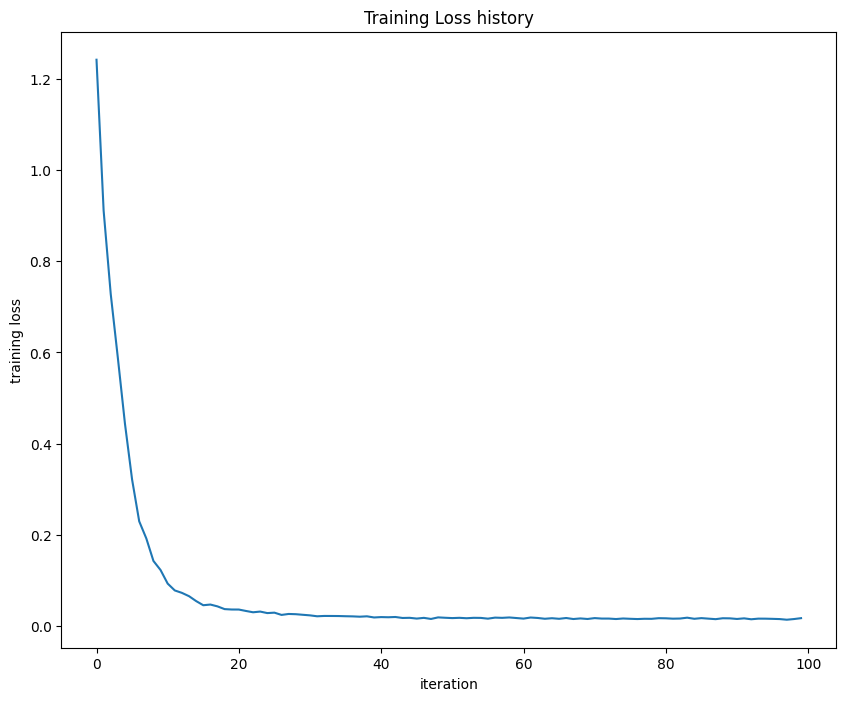

In [6]:
net = init_toy_model()
stats = net.train(X, y, X, y,
            learning_rate=1e-1, reg=5e-6,
            num_iters=100, verbose=False)

print('Final training loss: ', stats['loss_history'][-1])


plt.plot(stats['loss_history'])
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()

# Обучение нейронной сети на реальном наборе данных (CIFAR-10)

Загрузите набор данных, соответствующий вашему варианту. 

In [7]:
from scripts.data_utils import load_CIFAR10

cifar10_dir = 'scripts/datasets/cifar-10-batches-py'

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

d:\Учёба\4 курс\НС\DL_StrelnikovNA_6401\Lab_1-2\scripts\data_utils.py:15: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return  pickle.load(f, encoding='latin1')


Разделите данные на обучающую, тестовую и валидационную выборки.

In [8]:
num_training = 49000
num_validation = 1000
num_test = 10000

X_val = X_train[:num_validation]
y_val = y_train[:num_validation]

X_train = X_train[num_validation:num_validation + num_training]
y_train = y_train[num_validation:num_validation + num_training]

X_test = X_test[:num_test]
y_test = y_test[:num_test]

Выполните предобработку данных, как в ЛР 1. 

In [12]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_val = X_val.reshape(X_val.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print('Train shape:', X_train.shape)
print('Train labels:', y_train.shape)

print('Val shape:', X_val.shape)
print('Val labels:', y_val.shape)

print('Test shape:', X_test.shape)
print('Test labels:', y_test.shape)

Train shape: (49000, 3072)
Train labels: (49000,)
Val shape: (1000, 3072)
Val labels: (1000,)
Test shape: (10000, 3072)
Test labels: (10000,)


In [13]:
mean_image = np.mean(X_train, axis=0)

X_train -= mean_image
X_val -= mean_image
X_test -= mean_image

Обучите нейронную сеть на ваших данных. 

При сдаче лабораторной работы объясните значения всех параметров метода train.

In [14]:
input_size = 32 * 32 * 3
hidden_size = 50
num_classes = 10
net = TwoLayerNet(input_size, hidden_size, num_classes)

stats = net.train(X_train, y_train, X_val, y_val,
            num_iters=1000, batch_size=200,
            learning_rate=1e-4, learning_rate_decay=0.95,
            reg=0.25, verbose=True)

val_acc = (net.predict(X_val) == y_val).mean()
print('Validation accuracy: ', val_acc)

iteration 0 / 1000: loss 2.302973
iteration 100 / 1000: loss 2.302573
iteration 200 / 1000: loss 2.299192
iteration 300 / 1000: loss 2.269822
iteration 400 / 1000: loss 2.209679
iteration 500 / 1000: loss 2.171552
iteration 600 / 1000: loss 2.112717
iteration 700 / 1000: loss 2.009729
iteration 800 / 1000: loss 1.980612
iteration 900 / 1000: loss 2.021318
Validation accuracy:  0.288


Используя параметры по умолчанию, вы можете получить accuracy, примерно равный 0.29. 

Проведите настройку гиперпараметров для увеличения accuracy. Поэкспериментируйте со значениями гиперпараметров, например, с количеством скрытых слоев, количеством эпох, скорости обучения и др. Ваша цель - максимально увеличить accuracy полносвязной сети на валидационном наборе. Различные эксперименты приветствуются. Например, вы можете использовать методы для сокращения размерности признакового пространства (например, PCA), добавить dropout слои и др. 

Для лучшей модели вычислите acсuracy на тестовом наборе. 

Для отладки процесса обучения часто помогают графики изменения loss и accuracy в процессе обучения. Ниже приведен код построения таких графиков. 

### Для определения наилучшей модели будем последовательно перебирать каждый гиперпараметр, находя наилучший.

В первую очередь поэксперементируем с количеством скрытых слоев.

In [ ]:
best_acc = 0.0
best_hidden_size = 50
hidden_size_list = [50, 100, 200, 300, 500, 800]

for hidden_size in hidden_size_list:
    print(f"Current hidden size: {hidden_size}.")
    input_size = 32 * 32 * 3
    num_classes = 10
    net = TwoLayerNet(input_size, hidden_size, num_classes)

    stats = net.train(X_train, y_train, X_val, y_val,
                num_iters=1000, batch_size=200,
                learning_rate=1e-4, learning_rate_decay=0.95,
                reg=0.25, verbose=True)

    val_acc = (net.predict(X_val) == y_val).mean()
    if val_acc > best_acc:
        best_acc = val_acc
        best_hidden_size = hidden_size

    print('Validation accuracy: ', val_acc)

print(f"Best accuracy: {best_acc} with {best_hidden_size} hidden layers.")

Current hidden size: 50.
iteration 0 / 1000: loss 2.302987
iteration 100 / 1000: loss 2.302581
iteration 200 / 1000: loss 2.299313
iteration 300 / 1000: loss 2.268364
iteration 400 / 1000: loss 2.191517
iteration 500 / 1000: loss 2.102926
iteration 600 / 1000: loss 2.152907
iteration 700 / 1000: loss 2.060450
iteration 800 / 1000: loss 1.973619
iteration 900 / 1000: loss 1.926168
Validation accuracy:  0.293
Current hidden size: 100.
iteration 0 / 1000: loss 2.303349
iteration 100 / 1000: loss 2.302615
iteration 200 / 1000: loss 2.296762
iteration 300 / 1000: loss 2.252325
iteration 400 / 1000: loss 2.172233
iteration 500 / 1000: loss 2.108667
iteration 600 / 1000: loss 2.093410
iteration 700 / 1000: loss 2.079460
iteration 800 / 1000: loss 2.028270
iteration 900 / 1000: loss 2.037285
Validation accuracy:  0.319
Current hidden size: 200.
iteration 0 / 1000: loss 2.304091
iteration 100 / 1000: loss 2.302331
iteration 200 / 1000: loss 2.288323
iteration 300 / 1000: loss 2.215582
iteration

Итак, наилучшую точность модель дает при 500 скрытых слоях. Далее можно перебрать значения learning rate с определенным best_hidden_size и найти наилучший параметр best_learning_rate.

In [ ]:
best_acc = 0.0
best_learning_rate = 1e-3
learning_rate_list = [1e-3, 5e-3, 1e-2, 5e-2, 1e-1]

for learning_rate in learning_rate_list:
    print(f"Current learning rate: {learning_rate}.")
    input_size = 32 * 32 * 3
    num_classes = 10
    net = TwoLayerNet(input_size, best_hidden_size, num_classes)

    stats = net.train(X_train, y_train, X_val, y_val,
                num_iters=1000, batch_size=200,
                learning_rate=learning_rate, learning_rate_decay=0.95,
                reg=0.25, verbose=True)

    val_acc = (net.predict(X_val) == y_val).mean()
    if val_acc > best_acc:
        best_acc = val_acc
        best_learning_rate = learning_rate

    print('Validation accuracy: ', val_acc)

print(f"Best accuracy: {best_acc} with {best_learning_rate} learning rate.")

Current learning rate: 0.001.
iteration 0 / 1000: loss 2.306400
iteration 100 / 1000: loss 1.953837
iteration 200 / 1000: loss 1.820870
iteration 300 / 1000: loss 1.664758
iteration 400 / 1000: loss 1.507387
iteration 500 / 1000: loss 1.596706
iteration 600 / 1000: loss 1.635622
iteration 700 / 1000: loss 1.508716
iteration 800 / 1000: loss 1.572749
iteration 900 / 1000: loss 1.502567
Validation accuracy:  0.484
Current learning rate: 0.005.
iteration 0 / 1000: loss 2.306483


d:\Учёба\4 курс\НС\DL_StrelnikovNA_6401\Lab_1-2\scripts\classifiers\neural_net.py:108: RuntimeWarning: divide by zero encountered in log
  correct_logprobs = -np.log(probs[np.arange(N), y])


iteration 100 / 1000: loss inf
iteration 200 / 1000: loss inf
iteration 300 / 1000: loss inf
iteration 400 / 1000: loss inf
iteration 500 / 1000: loss inf
iteration 600 / 1000: loss inf
iteration 700 / 1000: loss inf
iteration 800 / 1000: loss inf
iteration 900 / 1000: loss inf


d:\Учёба\4 курс\НС\DL_StrelnikovNA_6401\Lab_1-2\scripts\classifiers\neural_net.py:249: RuntimeWarning: overflow encountered in dot
  scores = hidden.dot(self.params['W2']) + self.params['b2']
d:\Учёба\4 курс\НС\DL_StrelnikovNA_6401\Lab_1-2\scripts\classifiers\neural_net.py:103: RuntimeWarning: overflow encountered in subtract
  shifted_scores = scores - np.max(scores, axis=1, keepdims=True)
d:\Учёба\4 курс\НС\DL_StrelnikovNA_6401\Lab_1-2\scripts\classifiers\neural_net.py:85: RuntimeWarning: overflow encountered in dot
  scores = hidden.dot(W2) + b2
d:\Учёба\4 курс\НС\DL_StrelnikovNA_6401\Lab_1-2\scripts\classifiers\neural_net.py:103: RuntimeWarning: invalid value encountered in subtract
  shifted_scores = scores - np.max(scores, axis=1, keepdims=True)


Validation accuracy:  0.102
Current learning rate: 0.01.
iteration 0 / 1000: loss 2.306455
iteration 100 / 1000: loss inf
iteration 200 / 1000: loss inf
iteration 300 / 1000: loss inf
iteration 400 / 1000: loss nan
iteration 500 / 1000: loss nan
iteration 600 / 1000: loss nan
iteration 700 / 1000: loss nan
iteration 800 / 1000: loss nan
iteration 900 / 1000: loss nan
Validation accuracy:  0.102
Current learning rate: 0.05.
iteration 0 / 1000: loss 2.306465
iteration 100 / 1000: loss inf
iteration 200 / 1000: loss nan
iteration 300 / 1000: loss nan
iteration 400 / 1000: loss nan
iteration 500 / 1000: loss nan
iteration 600 / 1000: loss nan
iteration 700 / 1000: loss nan
iteration 800 / 1000: loss nan
iteration 900 / 1000: loss nan
Validation accuracy:  0.102
Current learning rate: 0.1.
iteration 0 / 1000: loss 2.306450


d:\Учёба\4 курс\НС\DL_StrelnikovNA_6401\Lab_1-2\scripts\classifiers\neural_net.py:85: RuntimeWarning: invalid value encountered in dot
  scores = hidden.dot(W2) + b2


iteration 100 / 1000: loss nan
iteration 200 / 1000: loss nan
iteration 300 / 1000: loss nan
iteration 400 / 1000: loss nan
iteration 500 / 1000: loss nan
iteration 600 / 1000: loss nan
iteration 700 / 1000: loss nan
iteration 800 / 1000: loss nan
iteration 900 / 1000: loss nan
Validation accuracy:  0.102
Best accuracy: 0.484 with 0.001 learning rate.


Переберем параметр регуляризации.

In [ ]:
best_acc = 0.0
best_reg = 1e-6
reg_list = [1e-6, 5e-6, 1e-5, 1e-4, 5e-4, 1e-3]

for reg in reg_list:
    print(f"Current reg: {reg}.")
    input_size = 32 * 32 * 3
    num_classes = 10
    net = TwoLayerNet(input_size, best_hidden_size, num_classes)

    stats = net.train(X_train, y_train, X_val, y_val,
                num_iters=1000, batch_size=200,
                learning_rate=best_learning_rate, learning_rate_decay=0.95,
                reg=reg, verbose=True)

    val_acc = (net.predict(X_val) == y_val).mean()
    if val_acc > best_acc:
        best_acc = val_acc
        best_reg = reg

    print('Validation accuracy: ', val_acc)

print(f"Best accuracy: {best_acc} with {best_reg} reg.")

Current reg: 1e-06.
iteration 0 / 1000: loss 2.302588
iteration 100 / 1000: loss 1.938489
iteration 200 / 1000: loss 1.637812
iteration 300 / 1000: loss 1.560426
iteration 400 / 1000: loss 1.515951
iteration 500 / 1000: loss 1.446252
iteration 600 / 1000: loss 1.419168
iteration 700 / 1000: loss 1.330132
iteration 800 / 1000: loss 1.470117
iteration 900 / 1000: loss 1.321617
Validation accuracy:  0.487
Current reg: 5e-06.
iteration 0 / 1000: loss 2.302588
iteration 100 / 1000: loss 1.941799
iteration 200 / 1000: loss 1.660762
iteration 300 / 1000: loss 1.689208
iteration 400 / 1000: loss 1.465362
iteration 500 / 1000: loss 1.639319
iteration 600 / 1000: loss 1.706101
iteration 700 / 1000: loss 1.413600
iteration 800 / 1000: loss 1.503620
iteration 900 / 1000: loss 1.366515
Validation accuracy:  0.476
Current reg: 1e-05.
iteration 0 / 1000: loss 2.302589
iteration 100 / 1000: loss 1.905609
iteration 200 / 1000: loss 1.637673
iteration 300 / 1000: loss 1.675754
iteration 400 / 1000: loss

Последним параметром переберем learning_rate_decay.

In [ ]:
best_acc = 0.0
best_lr_decay = 0.95
lr_decay_list = [0.95, 0.97, 0.98, 0.99]

for lr_decay in lr_decay_list:
    print(f"Current learning rate decay: {lr_decay}.")
    input_size = 32 * 32 * 3
    num_classes = 10
    net = TwoLayerNet(input_size, best_hidden_size, num_classes)

    stats = net.train(X_train, y_train, X_val, y_val,
                num_iters=1000, batch_size=200,
                learning_rate=best_learning_rate, learning_rate_decay=lr_decay,
                reg=best_reg, verbose=True)

    val_acc = (net.predict(X_val) == y_val).mean()
    if val_acc > best_acc:
        best_acc = val_acc
        best_lr_decay = lr_decay

    print('Validation accuracy: ', val_acc)

print(f"Best accuracy: {best_acc} with {best_lr_decay} learning rate decay.")

Current learning rate decay: 0.95.
iteration 0 / 1000: loss 2.302600
iteration 100 / 1000: loss 1.846132
iteration 200 / 1000: loss 1.698487
iteration 300 / 1000: loss 1.540728
iteration 400 / 1000: loss 1.509768
iteration 500 / 1000: loss 1.587456
iteration 600 / 1000: loss 1.467280
iteration 700 / 1000: loss 1.411609
iteration 800 / 1000: loss 1.306708
iteration 900 / 1000: loss 1.305017
Validation accuracy:  0.465
Current learning rate decay: 0.97.
iteration 0 / 1000: loss 2.302555
iteration 100 / 1000: loss 1.877218
iteration 200 / 1000: loss 1.814078
iteration 300 / 1000: loss 1.613375
iteration 400 / 1000: loss 1.592481
iteration 500 / 1000: loss 1.482498
iteration 600 / 1000: loss 1.420595
iteration 700 / 1000: loss 1.502349
iteration 800 / 1000: loss 1.529703
iteration 900 / 1000: loss 1.383024
Validation accuracy:  0.489
Current learning rate decay: 0.98.
iteration 0 / 1000: loss 2.302542
iteration 100 / 1000: loss 1.845087
iteration 200 / 1000: loss 1.714013
iteration 300 / 1

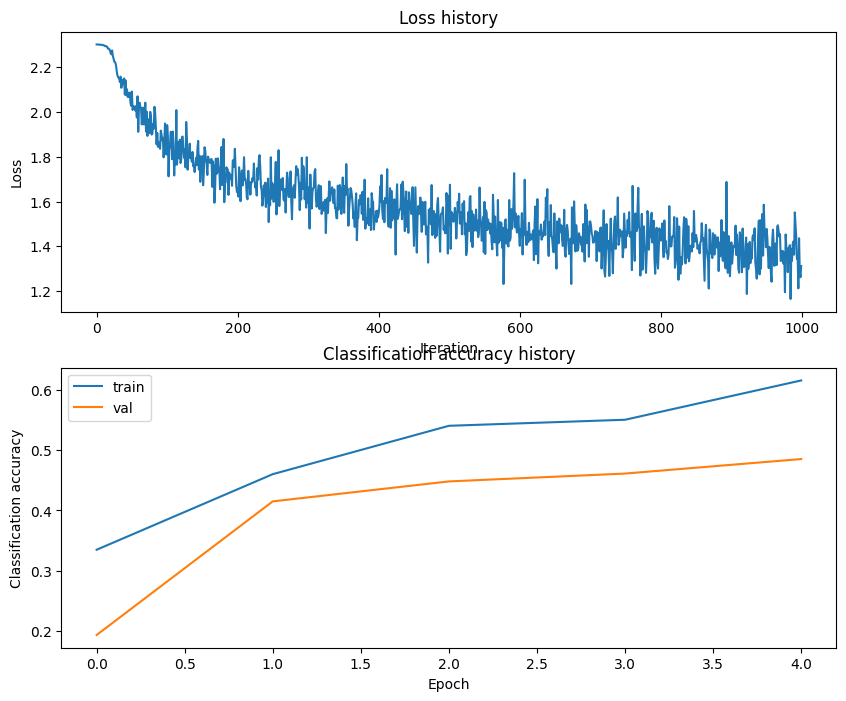

In [25]:
plt.subplot(2, 1, 1)
plt.plot(stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(stats['train_acc_history'], label='train')
plt.plot(stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.show()

В результате имеем модель с гиперпараметрами:

In [29]:
print(f"Best hidden layers: {best_hidden_size}.")
print(f"Best learning rate: {best_learning_rate}.")
print(f"Best reg: {best_reg}.")
print(f"Best learning rate decay: {best_lr_decay}.")


input_size = 32 * 32 * 3
num_classes = 10
net = TwoLayerNet(input_size, best_hidden_size, num_classes)

stats = net.train(X_train, y_train, X_val, y_val,
            num_iters=1000, batch_size=200,
            learning_rate=best_learning_rate, learning_rate_decay=best_lr_decay,
            reg=best_reg, verbose=True)

val_acc = (net.predict(X_val) == y_val).mean()
if val_acc > best_acc:
    best_acc = val_acc
    best_lr_decay = lr_decay

print('Validation accuracy: ', val_acc)

Best hidden layers: 500.
Best learning rate: 0.001.
Best reg: 0.0005.
Best learning rate decay: 0.99.
iteration 0 / 1000: loss 2.302654
iteration 100 / 1000: loss 1.767378
iteration 200 / 1000: loss 1.646750
iteration 300 / 1000: loss 1.533286
iteration 400 / 1000: loss 1.600029
iteration 500 / 1000: loss 1.475051
iteration 600 / 1000: loss 1.530521
iteration 700 / 1000: loss 1.398254
iteration 800 / 1000: loss 1.533801
iteration 900 / 1000: loss 1.301035
Validation accuracy:  0.464


Точность лучшей модели равна: 0.493.

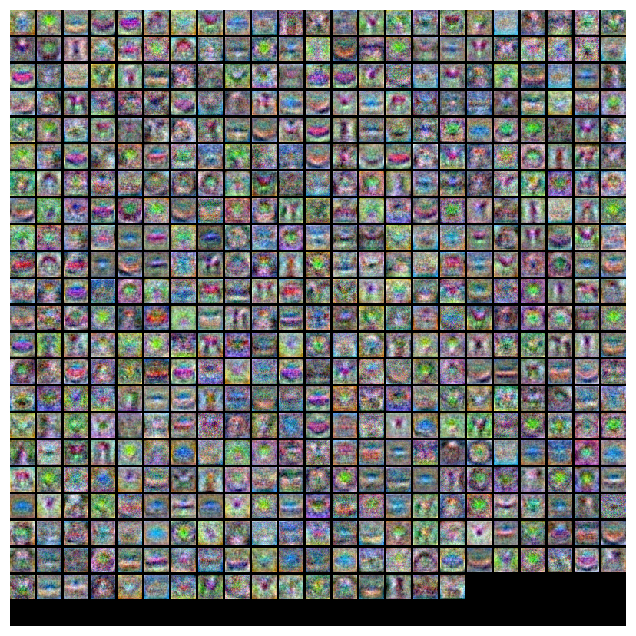

In [26]:
from scripts.vis_utils import visualize_grid

def show_net_weights(net):
    W1 = net.params['W1']
    W1 = W1.reshape(32, 32, 3, -1).transpose(3, 0, 1, 2)
    plt.imshow(visualize_grid(W1, padding=3).astype('uint8'))
    plt.gca().axis('off')
    plt.show()

show_net_weights(net)

Сделайте выводы по результатам работы. 

### Выводы

1. В ходе данной работы была реализована двухслойная нейронная сеть, выполняющая задачу классификации изображений.
2. Модель была протестирована на датасете CIFAR-10.
3. Модель по умолчанию показала точность равную 0.288. После ручного подбора гиперпараметров, за счет перебора разных значений, точность удалось повысить до 0.493, что значительно превосходит изначальный результат.
4. Параметры итоговой модели:
 - Best hidden layers: 500.
 - Best learning rate: 0.001.
 - Best reg: 0.0005.
 - Best learning rate decay: 0.99.
5. Также было установлено, что увеличение размера скрытого слоя улучшает качество модели, однако приводит к росту вычислительных затрат.